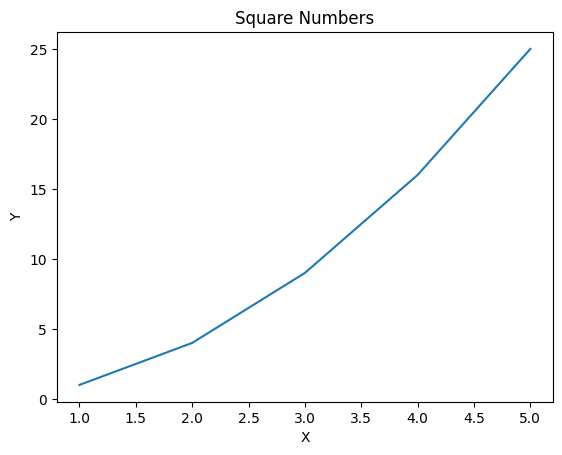

In [2]:
# Listing 1.1 Imperative library

import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y)
plt.title('Square Numbers')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

In [3]:
# Listing 1.2 Imperative library

import altair as alt
import pandas as pd

df = pd.DataFrame({'x': [1, 2, 3, 4, 5], 'y': [1, 4, 9, 16, 25]})

chart = alt.Chart(df).mark_line().encode(
    x='x',
    y='y'
).properties(
    title='Square Numbers'
)

chart


alt.Chart(...)

In [4]:
# Listing 2.1 Chart in Altair

import altair as alt
import pandas as pd

# Create data for the DataFrame
data = {'Name': ['Alice', 'Bob', 'Charlie'],
        'Age': [25, 30, 35],
        'City': ['New York', 'Paris', 'London']
}

# Create the DataFrame from the data
df = pd.DataFrame(data)

# Print the dataframe
print(df)

# Create the chart
chart = alt.Chart(df)


      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
2  Charlie   35    London


In [5]:
# Listing 2.2 Mark in Altair

chart = alt.Chart(df).mark_bar()

In [6]:
# Listing 2.3 Encodings in Altair

import pandas as pd
import altair as alt

# Create data for the DataFrame
data = {'Name': ['Alice', 'Bob', 'Charlie'],
        'Age': [25, 30, 35],
        'City': ['New York', 'Paris', 'London']
}


# Create the DataFrame from the data
df = pd.DataFrame(data)

# Create the chart
chart = alt.Chart(df).mark_bar(
).encode(
    x = 'Age:Q',
    y = 'Name:N'
)

chart.save('chart.html')

# to plot the chart inline.
chart.display()

alt.Chart(...)

In [7]:
# save to laptop
# - you will be prompted to provide the destination

from google.colab import files
files.download('/content/chart.html')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# Listing 2.4 Loading the dataset as a Pandas DataFrame

# import file from laptop
# from google.colab import files
# uploaded = files.upload()
#
# The aboved failed. uploaded file manually using "upload" command from "content"
#   folder context menu

import pandas as pd

df = pd.read_csv('/content/tourist_arrivals_countries.csv', parse_dates=['Date'])


In [ ]:
# Listing 2.5 Building a summary report

In [12]:
# install missing module ydata_profiling
# !pip install ydata_profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.3/357.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.5/679.5 kB 21.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 40.5 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=47626ebe1187ffd3286c65172cbd3cea0866251df21eb4bd80b2682416db86f4
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.3.0
    Uninstalling pydantic-2.3.0:
      Successfully uninstalled pydantic-2.3.0


In [13]:
from ydata_profiling import ProfileReport

eda = ProfileReport(df)
eda.to_file(output_file='eda.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
# Listing 2.6 Building the raw chart in Altair

import altair as alt

df2 = pd.melt(df,
              id_vars='Date',
              value_name='Tourist Arrivals',
              var_name='Country')

chart = alt.Chart(df2).mark_line().encode(
    x = 'Date:T',
    y = 'Tourist Arrivals:Q',
    color=alt.Color('Country:N')
)

chart.save('chart.html')

In [15]:
# Listing 2.7 Removing missing values from the dataset

mask_fr = df['FR'].isnull() == False
mask_uk = df['UK'].isnull() == False
mask_es = df['ES'].isnull() == False
df = df[(mask_fr) & (mask_uk) & (mask_es)]

In [19]:
# Listing 2.8 Grouping by year and calculating the average value

# group data by year and calculate the average value
# select only data for 1994 (the first in the dataset) and 2018 (the penultimate in the dataset).

df2 = df.copy()
df2.loc[:, 'Year'] = df['Date'].dt.year

# What is this line doing: df2.loc[:, 'Year'] = df['Date'].dt.year

# This line of code is performing two main operations:

# df['Date'].dt.year:
# It extracts the year from the Date column of the DataFrame df. The .dt
#   accessor is used to extract date-related attributes from a pandas Series or
#   DataFrame column of type datetime64[ns]. Here, .year retrieves the year from
#    the date.

# df2.loc[:, 'Year'] = ...:
# This part is assigning the extracted year values to a new column named 'Year'
#   in the DataFrame df2.

# So, in summary, the code is creating (or updating) a column named 'Year' in
#   the DataFrame df2, where each entry in this column corresponds to the year
#   extracted from the Date column of the df DataFrame.


df2 = df2.groupby(by='Year').mean(numeric_only=True)
df2 = df2.iloc[[0, -2]]
df2.reset_index(inplace=True)

# df2 = df2.groupby(by='Year').mean(numeric_only=True)
#  This line groups the df2 DataFrame by unique values in the 'Year' column.
#  After grouping, it calculates the mean of all numeric columns for each unique
#    'Year'.
#  The result is a new DataFrame where each row represents a unique 'Year', and
#    the columns contain the average values for that year.
#  numeric_only=True ensures that the mean is calculated only for numeric
#   columns.

# df2 = df2.iloc[[0, -2]]
#  This line selects the first row and the second-to-last row of the df2
#   DataFrame.
#  iloc is used for integer-location based indexing, and the indices [0, -2]
#   represent the first and second-to-last rows respectively.
#  The resulting DataFrame df2 will now only have two rows: the first and the
#   second-to-last rows from the original df2 (which was the grouped and
#   averaged DataFrame).

# df2.reset_index(inplace=True)
#  After grouping by 'Year', the 'Year' values become the index of the DataFrame.
#  This line resets the index of df2 to the default integer index.
#  The original 'Year' index will become a column in the DataFrame.
#  inplace=True means the operation is done in-place, and the DataFrame is
#    modified directly without the need to reassign it.

# In summary, the code is grouping the DataFrame df2 by 'Year', calculating the
#   mean of numeric columns for each year, then selecting only the first and
#   second-to-last rows, and finally resetting the DataFrame's index so that
#   'Year' becomes a regular column again.

In [23]:
# Listing 2.9 Building the chart in Altair

df3 = pd.melt(df2, id_vars='Year',value_name='Tourist Arrivals', var_name='Country')

chart = alt.Chart(df3).mark_line(point=alt.OverlayMarkDef()).encode(
    x = alt.X('Year:O',
    title='',
    axis=alt.Axis(labelAngle=0)),
    y = 'Tourist Arrivals:Q',
    color=alt.Color('Country:N')
).properties(
    width=400,
    height=300,
    title='Countries Trend in Arrivals'
)


# chart.save(‘chart.html’)
chart.save('chart_2_9.html')

In [24]:
# Listing 2.10 Preparing the DataFrame

mask = df3['Country'] == 'PT'
df4 = df3.loc[~mask].groupby('Year').mean().reset_index()
df4['Country'] = 'Others (mean)'
df5 = df3.loc[mask].append(df4, ignore_index=True)

<ipython-input-24-bcfb1164f286>:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df4 = df3.loc[~mask].groupby('Year').mean().reset_index()
<ipython-input-24-bcfb1164f286>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df5 = df3.loc[mask].append(df4, ignore_index=True)


In [25]:
# display results to compare to Table 2.2

,Year,Country,Tourist Arrivals
0,1994,PT,5.633548e+05
1,2018,PT,1.703339e+06
2,1994,Others (mean),4.503851e+06
3,2018,Others (mean),9.082776e+06


In [27]:
# Listing 2.11 Drawing the chart with Portugal and Average

chart = alt.Chart(df5).mark_line(point=alt.OverlayMarkDef()).encode(
    x = alt.X('Year:O', title='', axis=alt.Axis(labelAngle=0)),
    y = 'Tourist Arrivals:Q',
    color=alt.Color('Country:N')
).properties(
    width=400,
    height=300,
    title='Countries Trend in Arrivals'
)
chart.save('chart_2_11.html')

In [28]:
# Listing 2.12 Calculating the percentage increase for each country

mask_first = df5['Year'] == 1994
mask_last = df5['Year'] == 2018
mask_pt = df5['Country'] == 'PT'
mask_ot = df5['Country'] == 'Others (mean)'

pi_pt = (df5[mask_last & mask_pt]['Tourist Arrivals'].values[0] - \
        df5[mask_first & mask_pt]['Tourist Arrivals'].values[0]) / \
        df5[mask_first & mask_pt]['Tourist Arrivals'].values[0]*100

pi_ot = (df5[mask_last & mask_ot]['Tourist Arrivals'].values[0] - \
        df5[mask_first & mask_ot]['Tourist Arrivals'].values[0]) / \
        df5[mask_first & mask_ot]['Tourist Arrivals'].values[0]*100

In [29]:
# Listing 2.13 Drawing the chart of percentage increases

df_pi = pd.DataFrame({
    'Date'    : [1994,2018,1994,2018],
    'Country' : ['PT', 'PT', 'Others (mean)', 'Others (mean)'],
    'Tourist Arrivals' : [0, pi_pt, 0, pi_ot]
})


chart = alt.Chart(df_pi).mark_line(point=alt.OverlayMarkDef()).encode(
    x = alt.X('Date:O', title='', axis=alt.Axis(labelAngle=0)),
    y = alt.Y('Tourist Arrivals:Q',title='%'),
    color=alt.Color('Country:N')
).properties(
    width=400,
    height=300,
    title='Percentage increase in Tourist Arrivals'
)

chart.save('chart_2_13.html')

In [31]:
# Listing 2.14 Adding an annotation to the chart

df_ann = pd.DataFrame({
    'Text' : ['Portugal: ' +
              '{:.2f}'.format(pi_pt) +
              '%',
              'Others (mean): ' +
              '{:.2f}'.format(pi_ot) + '%'],
    'Y' : [pi_pt,pi_ot],
    'X' : [2018,2018],
    'Country' : ['PT', 'Others (mean)']
})

pi = alt.Chart(df_ann).mark_text(
    dx=10,
    align='left',
    fontSize=20
).encode(
    text='Text:N',
    y='Y:Q',
    x='X:O',
    color=alt.Color('Country:N',
                    scale=alt.Scale(domain=['Others (mean)', 'PT'],
                    range=['lightgrey', '#81c01e']),
                    legend=None)
)
total = (chart + pi).configure_view(strokeWidth=0)
total.save('chart_2_14.html')

In [1]:
# Listing 2.15 Adding the context to the chart

annotation = f"""Thanks to the introduction ..."""
df_text = pd.DataFrame([{'text' : annotation}])

text = alt.Chart(df_text
).mark_text(
    lineBreak='\n',
    align='left',
    fontSize=20,
    y=100,
    color='orange'
).encode(
    text='text:N'
)

# build the final chart
total = (text | chart + pi).configure_view(strokeWidth=0)
total.save('chart.html')

NameError: ignored

# New Section